<a href="https://colab.research.google.com/github/httpMatheus-dev/inteligencia-artificial-umc/blob/main/fishmorph_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de famílias de peixes com SVM
Dataset: FISHMORPH (medidas morfológicas -> família do peixe)

# Matheus Gabriel Alves da Silva
**RGM:** 11241100109

**Disciplina:** Inteligência Artificial  
**Curso:** Engenharia de Software  
**Turma:** 6B — Noite  

## 1. Importar o dataset

In [14]:
import kagglehub

path = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
Path to dataset files: /kaggle/input/fishmorph-dataset


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
df = pd.read_csv(os.path.join(path, "FISHMORPH_Family_Dataset.csv"))
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


## 2. Análise padrão dos dados
Tamanho, tipos, estatísticas, nulos e duplicadas.

In [17]:
print(df.shape)
print()
df.info()
print()
print(df.describe())
print()
print("Nulos:\n", df.isnull().sum())
print()
print("Duplicadas:", df.duplicated().sum())

(8342, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB

               MBl          BEl          VEp          REs          OGp  \
count  8342.000000  8342.000000  8342.000000  8342.000000  8342.000000   
mean     22.004517     4.452438     0.549087     0.391665     0.381768   
std      33.612007     2.338235     0.094883     0.132814     0.194352   
min       1.200000     1.033084     0.159248    

Não há nulos. Removendo a linha duplicada:

In [18]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

(8341, 11)


## 3. Distribuição das categorias
A coluna alvo é `Family`.

Family
Cyprinidae         1545
Cichlidae          1060
Characidae          732
Loricariidae        427
Percidae            190
                   ... 
Sillaginidae          1
Serrasalmidae         1
Bythitidae            1
Vaillantellidae       1
Valenciidae           1
Name: count, Length: 197, dtype: int64
Nº de famílias: 197


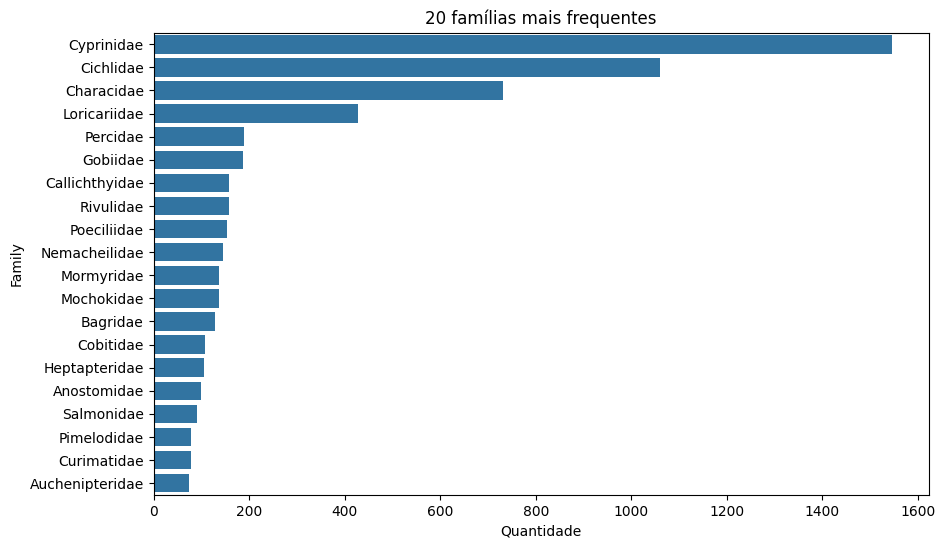

In [19]:
target = "Family"

contagem = df[target].value_counts()
print(contagem)
print("Nº de famílias:", df[target].nunique())

# Gráfico das 20 famílias mais frequentes
plt.figure(figsize=(10, 6))
sns.barplot(x=contagem.head(20).values, y=contagem.head(20).index)
plt.title("20 famílias mais frequentes")
plt.xlabel("Quantidade")
plt.show()

Distribuição das variáveis numéricas e correlação entre elas:

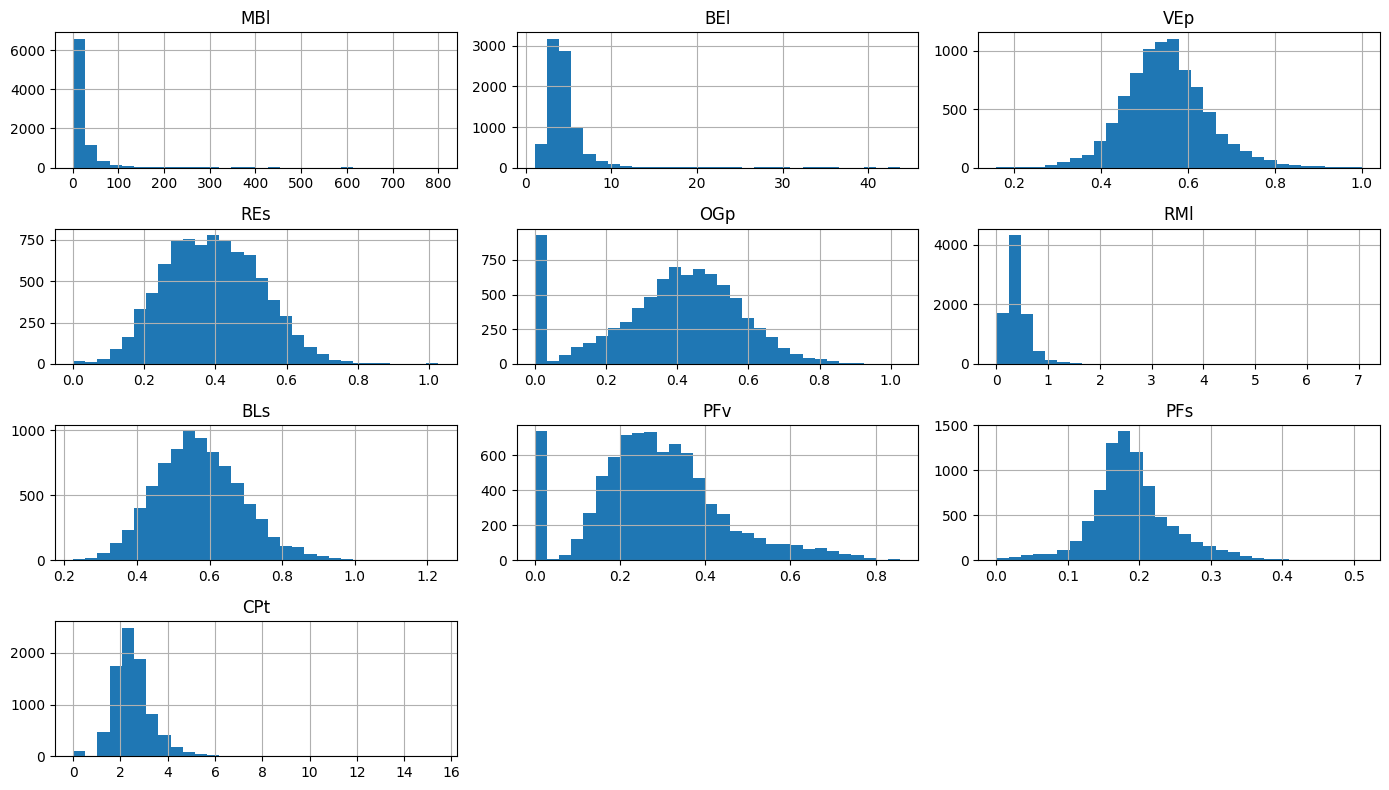

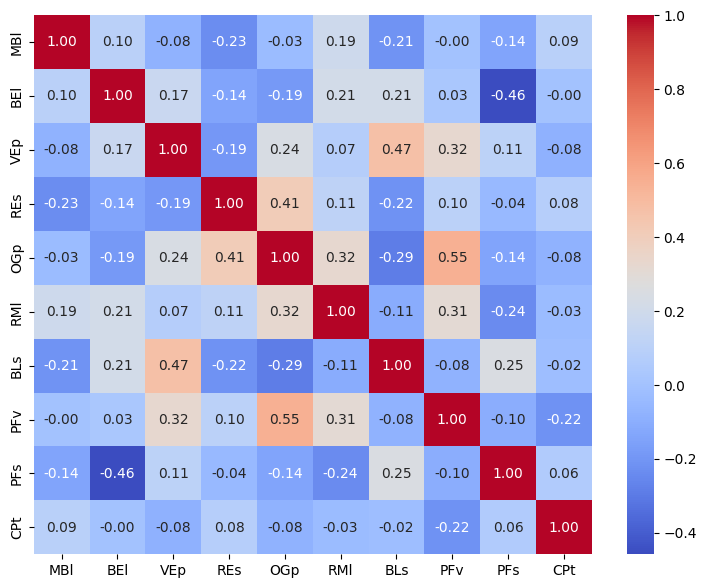

In [20]:
features = df.drop(columns=[target])

features.hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

## 4. Filtro de famílias raras
Várias famílias têm só 1 exemplo, o que impede a divisão estratificada e a validação cruzada.
Mantemos apenas famílias com **pelo menos 10 amostras**.

In [21]:
MIN_AMOSTRAS = 10
familias_validas = contagem[contagem >= MIN_AMOSTRAS].index
df_f = df[df[target].isin(familias_validas)].reset_index(drop=True)

print("Famílias antes:", df[target].nunique(), "| depois:", df_f[target].nunique())
print("Linhas antes:", len(df), "| depois:", len(df_f))

Famílias antes: 197 | depois: 90
Linhas antes: 8341 | depois: 7999


## 5. Divisão treino / teste
80% treino, 20% teste, mantendo a proporção das famílias (`stratify`).

In [22]:
X = df_f.drop(columns=[target])
y = df_f[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (6399, 10) | Teste: (1600, 10)


## 6. Grid Search com validação cruzada
4 valores para cada hiperparâmetro (`kernel`, `C` e `gamma`), com `cv=5`.
O `StandardScaler` fica dentro do Pipeline para não vazar dados da validação.

> Pode demorar alguns minutos. Se ficar lento, troque `cv=5` por `cv=3`.

In [23]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

param_grid = {
    "svc__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svc__C":      [0.1, 1, 10, 100],
    "svc__gamma":  [0.001, 0.01, 0.1, 1],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1],
                         'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=1)

## 7. Melhor modelo e parâmetros

In [24]:
print("Modelo:", grid.best_estimator_.named_steps["svc"])
print("Melhores parâmetros:", grid.best_params_)
print("Acurácia média na validação cruzada:", round(grid.best_score_, 4))

Modelo: SVC(C=100, gamma=0.01)
Melhores parâmetros: {'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Acurácia média na validação cruzada: 0.6768


## 8. Acurácia no teste e matriz de confusão

In [25]:
y_pred = grid.predict(X_test)

print("Acurácia no teste:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Acurácia no teste: 0.6744

                   precision    recall  f1-score   support

   Abyssocottidae       0.33      0.25      0.29         4
Acestrorhynchidae       0.60      1.00      0.75         3
        Achiridae       0.00      0.00      0.00         2
    Acipenseridae       1.00      1.00      1.00         4
         Akysidae       0.50      0.33      0.40         3
        Alestidae       0.00      0.00      0.00        15
       Ambassidae       0.80      0.80      0.80         5
   Amblycipitidae       0.50      0.33      0.40         3
      Amphiliidae       0.83      0.62      0.71         8
      Anabantidae       1.00      0.75      0.86         4
      Anablepidae       0.00      0.00      0.00         2
      Anguillidae       1.00      1.00      1.00         2
      Anostomidae       0.89      0.40      0.55        20
    Aplocheilidae       0.24      0.31      0.27        13
    Apteronotidae       0.80      0.57      0.67         7
          Ariidae       0.50

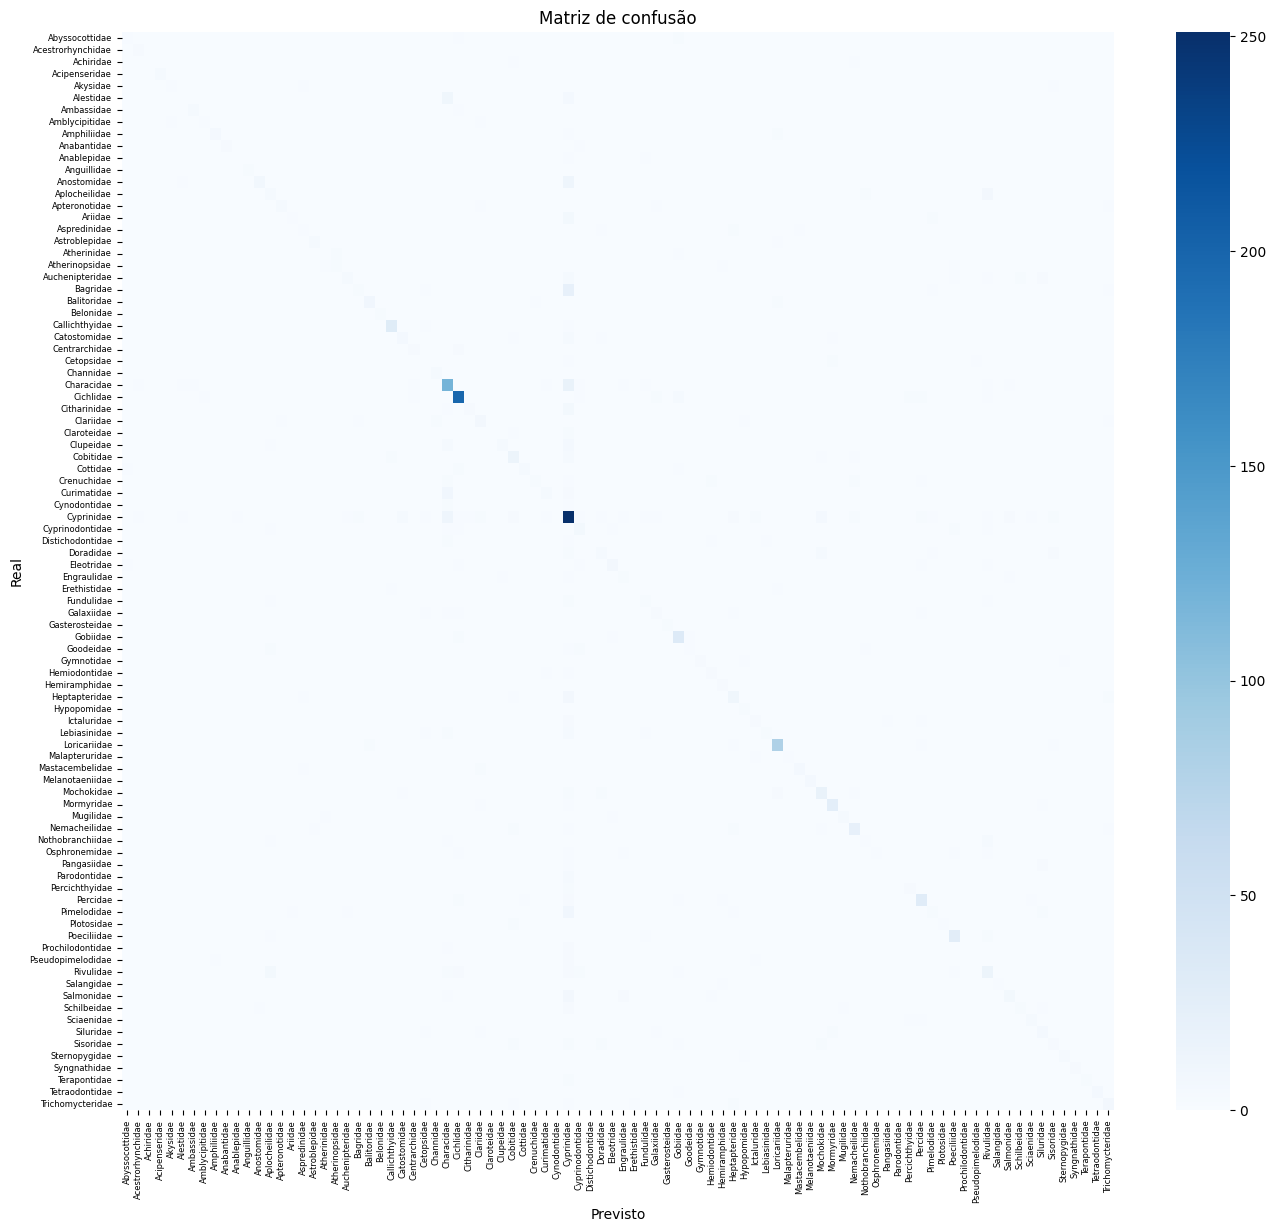

In [26]:
cm = confusion_matrix(y_test, y_pred, labels=grid.classes_)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=grid.classes_, yticklabels=grid.classes_)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.show()

## 9. Conclusão
- **Modelo:** SVC (Support Vector Classifier), kernel **rbf**
- **Parâmetros:** **C = 100** e **gamma = 0.01**
- **Acurácia (validação cruzada, cv=5):** **67,68%**
- **Acurácia (teste):** **67,44%**

Observações:
- Famílias com menos de 10 amostras foram removidas (197 → 90 famílias; 8.341 → 7.999 linhas), pois não permitem divisão estratificada nem validação cruzada. O resultado vale apenas para as 90 famílias restantes.
- A acurácia na validação cruzada (67,68%) e no teste (67,44%) são muito próximas, o que indica que o modelo não sofreu overfitting.
- O dataset é desbalanceado (ex.: Cyprinidae tem muito mais exemplos que as demais), então o modelo tende a acertar mais as famílias grandes. O `classification_report` mostra isso: o f1-score médio (macro avg) é 0,50, bem abaixo da acurácia. Famílias pequenas como Pangasiidae, Parodontidae e Prochilodontidae tiveram f1 = 0, enquanto famílias como Mormyridae, Poeciliidae e Tetraodontidae passaram de 0,84.
- O melhor valor de C (100) é o maior testado no grid, então um C maior poderia melhorar um pouco o resultado.